# Итоговое задание по дисциплине «Основы машинного обучения»

**Суть проекта** — построить модель классификации изображений, которая автоматически определяет класс объекта на картинке.

Сразу обозначим, что нейросети применять не придется — на этом наборе данных достаточно будет методов классического ML, а сам датасет уже подготовлен и содержит разделенные по столбцам пиксели. Зато можно задействовать все возможности ML: и обучение с учителем, и без учителя.

Постарайтесь оформить исследовательский ноутбук, провести эксперименты на разных этапах, найти наиболее подходящие алгоритмы, фиксируя промежуточные наблюдения в выводах. Чтобы обосновать выбор моделей и гиперпараметров, важно также провести разведывательный анализ данных и выполнить предварительную обработку данных.

Ниже найдете более подробную инструкцию по выполнению проекта.

**Критерии оценивания**

| Задание                                            | Балл      |
| -------------------------------------------------- | --------- |
| Задание 1        | 0.8 |
| Задание 2        | 0.8 |
| Задание 3        | 0.7 |
| Задание 4        | 1  |
| Задание 5        | 1.5  |
| Задание 6        | 2  |
| Задание 7        | 1.7 |
| Задание 8        | 1.5  |

## Описание данных

В работе используется известный набор данных **MNIST (Modified National Institute of Standards and Technology)** в его полной версии из `sklearn.datasets.fetch_openml`. Этот датасет предназначен для задачи классификации рукописных цифр и является одним из самых часто используемых бенчмарков в машинном обучении и компьютерном зрении.

Данные содержат набор изображений в градациях серого, каждое из них представлено в виде матрицы интенсивностей и соответствует одной из цифр.


In [ ]:
#pip install -q optuna

In [86]:
# ячейка с импортами — дополняйте по своему желанию
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import linear_model
from sklearn import svm
from sklearn import tree
from sklearn import ensemble

import catboost as cb

import optuna
from optuna.samplers import TPESampler

from warnings import simplefilter
simplefilter(action='ignore')

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", 10000)

## Задание 1. Знакомство с данными

Сначала познакомимся с датасетом:
1. Загрузите датасет с помощью [`sklearn.datasets.fetch_openml`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html).
2. Познакомьтесь с данными: проверьте наличие стандартных проблем по типу пропусков, дублей и ошибочных значений-выбросов. Что вообще можно считать выбросом в таком датасете?
3. Визуализируйте 5 случайных изображений, полезная функция для этого [`matplotlib.pyplot.imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html).
4. Сколько изображений в датасете и какого они размера? Достаточно ли этого для обучения ML-моделей?

Не забудьте зафиксировать все наблюдения в выводе.

In [19]:
"""
ВАШЕ РЕШЕНИЕ
"""

mnist_nums = fetch_openml('mnist_784', version=1)
nums_data = pd.DataFrame(data=mnist_nums.data)
nums_data['digit'] = mnist_nums.target

display(nums_data.sample(10))

print(f'Количество строк в датасете: {nums_data.shape[0]}')
print(f'Количество столбцов в датасете: {nums_data.shape[1]}')

display(nums_data.info())

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pixel119,pixel120,pixel121,pixel122,pixel123,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel139,pixel140,pixel141,pixel142,pixel143,pixel144,pixel145,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel161,pixel162,pixel163,pixel164,pixel165,pixel166,pixel167,pixel168,pixel169,pixel170,pixel171,pixel172,pixel173,pixel174,pixel175,pixel176,pixel177,pixel178,pixel179,pixel180,pixel181,pixel182,pixel183,pixel184,pixel185,pixel186,pixel187,pixel188,pixel189,pixel190,pixel191,pixel192,pixel193,pixel194,pixel195,pixel196,pixel197,pixel198,pixel199,pixel200,pixel201,pixel202,pixel203,pixel204,pixel205,pixel206,pixel207,pixel208,pixel209,pixel210,pixel211,pixel212,pixel213,pixel214,pixel215,pixel216,pixel217,pixel218,pixel219,pixel220,pixel221,pixel222,pixel223,pixel224,pixel225,pixel226,pixel227,pixel228,pixel229,pixel230,pixel231,pixel232,pixel233,pixel234,pixel235,pixel236,pixel237,pixel238,pixel239,pixel240,pixel241,pixel242,pixel243,pixel244,pixel245,pixel246,pixel247,pixel248,pixel249,pixel250,...,pixel536,pixel537,pixel538,pixel539,pixel540,pixel541,pixel542,pixel543,pixel544,pixel545,pixel546,pixel547,pixel548,pixel549,pixel550,pixel551,pixel552,pixel553,pixel554,pixel555,pixel556,pixel557,pixel558,pixel559,pixel560,pixel561,pixel562,pixel563,pixel564,pixel565,pixel566,pixel567,pixel568,pixel569,pixel570,pixel571,pixel572,pixel573,pixel574,pixel575,pixel576,pixel577,pixel578,pixel579,pixel580,pixel581,pixel582,pixel583,pixel584,pixel585,pixel586,pixel587,pixel588,pixel589,pixel590,pixel591,pixel592,pixel593,pixel594,pixel595,pixel596,pixel597,pixel598,pixel599,pixel600,pixel601,pixel602,pixel603,pixel604,pixel605,pixel606,pixel607,pixel608,pixel609,pixel610,pixel611,pixel612,pixel613,pixel614,pixel615,pixel616,pixel617,pixel618,pixel619,pixel620,pixel621,pixel622,pixel623,pixel624,pixel625,pixel626,pixel627,pixel628,pixel629,pixel630,pixel631,pixel632,pixel633,pixel634,pixel635,pixel636,pixel637,pixel638,pixel639,pixel640,pixel641,pixel642,pixel643,pixel644,pixel645,pixel646,pixel647,pixel648,pixel649,pixel650,pixel651,pixel652,pixel653,pixel654,pixel655,pixel656,pixel657,pixel658,pixel659,pixel660,pixel661,pixel662,pixel663,pixel664,pixel665,pixel666,pixel667,pixel668,pixel669,pixel670,pixel671,pixel672,pixel673,pixel674,pixel675,pixel676,pixel677,pixel678,pixel679,pixel680,pixel681,pixel682,pixel683,pixel684,pixel685,pixel686,pixel687,pixel688,pixel689,pixel690,pixel691,pixel692,pixel693,pixel694,pixel695,pixel696,pixel697,pixel698,pixel699,pixel700,pixel701,pixel702,pixel703,pixel704,pixel705,pixel706,pixel707,pixel708,pixel709,pixel710,pixel711,pixel712,pixel713,pixel714,pixel715,pixel716,pixel717,pixel718,pixel719,pixel720,pixel721,pixel722,pixel723,pixel724,pixel725,pixel726,pixel727,pixel728,pixel729,pixel730,pixel731,pixel732,pixel733,pixel734,pixel735,pixel736,pixel737,pixel738,pixel739,pixel740,pixel741

Количество строк в датасете: 70000
Количество столбцов в датасете: 785
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel1 to digit
dtypes: category(1), int64(784)
memory usage: 418.8 MB


None

In [20]:
display(nums_data.describe())
nums_data.describe(include="category")

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pixel119,pixel120,pixel121,pixel122,pixel123,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel139,pixel140,pixel141,pixel142,pixel143,pixel144,pixel145,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel161,pixel162,pixel163,pixel164,pixel165,pixel166,pixel167,pixel168,pixel169,pixel170,pixel171,pixel172,pixel173,pixel174,pixel175,pixel176,pixel177,pixel178,pixel179,pixel180,pixel181,pixel182,pixel183,pixel184,pixel185,pixel186,pixel187,pixel188,pixel189,pixel190,pixel191,pixel192,pixel193,pixel194,pixel195,pixel196,pixel197,pixel198,pixel199,pixel200,pixel201,pixel202,pixel203,pixel204,pixel205,pixel206,pixel207,pixel208,pixel209,pixel210,pixel211,pixel212,pixel213,pixel214,pixel215,pixel216,pixel217,pixel218,pixel219,pixel220,pixel221,pixel222,pixel223,pixel224,pixel225,pixel226,pixel227,pixel228,pixel229,pixel230,pixel231,pixel232,pixel233,pixel234,pixel235,pixel236,pixel237,pixel238,pixel239,pixel240,pixel241,pixel242,pixel243,pixel244,pixel245,pixel246,pixel247,pixel248,pixel249,pixel250,...,pixel535,pixel536,pixel537,pixel538,pixel539,pixel540,pixel541,pixel542,pixel543,pixel544,pixel545,pixel546,pixel547,pixel548,pixel549,pixel550,pixel551,pixel552,pixel553,pixel554,pixel555,pixel556,pixel557,pixel558,pixel559,pixel560,pixel561,pixel562,pixel563,pixel564,pixel565,pixel566,pixel567,pixel568,pixel569,pixel570,pixel571,pixel572,pixel573,pixel574,pixel575,pixel576,pixel577,pixel578,pixel579,pixel580,pixel581,pixel582,pixel583,pixel584,pixel585,pixel586,pixel587,pixel588,pixel589,pixel590,pixel591,pixel592,pixel593,pixel594,pixel595,pixel596,pixel597,pixel598,pixel599,pixel600,pixel601,pixel602,pixel603,pixel604,pixel605,pixel606,pixel607,pixel608,pixel609,pixel610,pixel611,pixel612,pixel613,pixel614,pixel615,pixel616,pixel617,pixel618,pixel619,pixel620,pixel621,pixel622,pixel623,pixel624,pixel625,pixel626,pixel627,pixel628,pixel629,pixel630,pixel631,pixel632,pixel633,pixel634,pixel635,pixel636,pixel637,pixel638,pixel639,pixel640,pixel641,pixel642,pixel643,pixel644,pixel645,pixel646,pixel647,pixel648,pixel649,pixel650,pixel651,pixel652,pixel653,pixel654,pixel655,pixel656,pixel657,pixel658,pixel659,pixel660,pixel661,pixel662,pixel663,pixel664,pixel665,pixel666,pixel667,pixel668,pixel669,pixel670,pixel671,pixel672,pixel673,pixel674,pixel675,pixel676,pixel677,pixel678,pixel679,pixel680,pixel681,pixel682,pixel683,pixel684,pixel685,pixel686,pixel687,pixel688,pixel689,pixel690,pixel691,pixel692,pixel693,pixel694,pixel695,pixel696,pixel697,pixel698,pixel699,pixel700,pixel701,pixel702,pixel703,pixel704,pixel705,pixel706,pixel707,pixel708,pixel709,pixel710,pixel711,pixel712,pixel713,pixel714,pixel715,pixel716,pixel717,pixel718,pixel719,pixel720,pixel721,pixel722,pixel723,pixel724,pixel725,pixel726,pixel727,pixel728,pixel729,pixel730,pixel731,pixel732,pixel733,pixel734,pixel735,pixel736,pixel737,pixel738,pixel739,pixel740

,digit
count,70000
unique,10
top,1
freq,7877


In [21]:
# Изменение формата всех ячеек на int
nums_data = nums_data.astype(int)

# Уникальные значения таргета
print('Уникальные значения таргета:')
print(nums_data['digit'].unique())

Уникальные значения таргета:
[5 0 4 1 9 2 3 6 7 8]


In [22]:
# Уникальные значения пикселей
values_set = set()
for i in range(784):
    lst = list(nums_data[nums_data.columns[i]].unique())
    values_set.update(lst)
print('Уникальные значения пикселей:')
print(values_set)

Уникальные значения пикселей:
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69),

In [23]:
# Проверка на ошибочные значения-выбросов
left_dev = {x for x in values_set if x < 0}
right_dev = {x for x in values_set if x > 255}

print(f'Количество выбросов слева: {len(left_dev)}')
print(f'Количество выбросов справа: {len(right_dev)}')

Количество выбросов слева: 0
Количество выбросов справа: 0


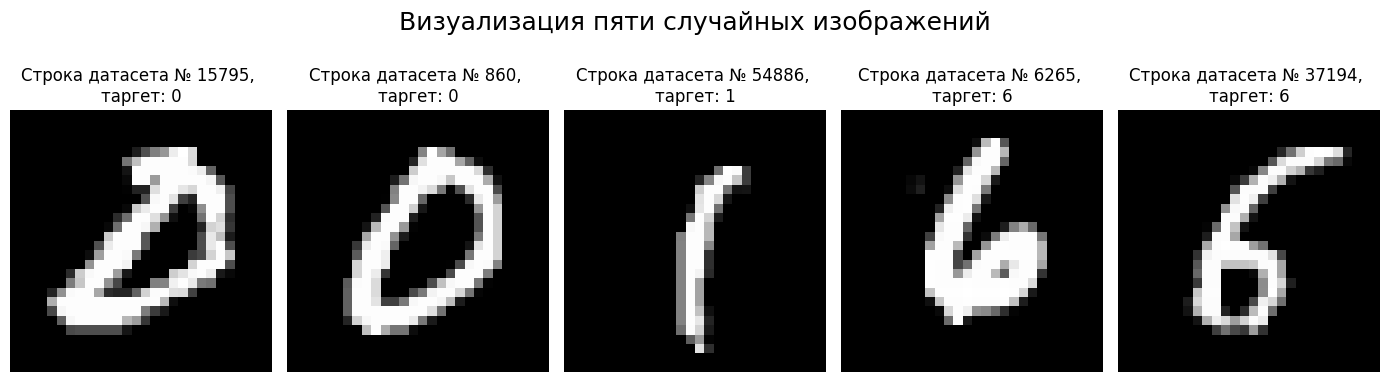

In [24]:
# Визуализация пяти случайных изображений
np.random.seed(42)
row_nums = np.random.randint(0, 69999, 5)

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
for i, row_num in enumerate(row_nums):
    row_data = nums_data.iloc[row_num, :-1].values
    img = row_data.reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f"Строка датасета № {row_num}, \nтаргет: {nums_data.iloc[row_num, 784]}"
    )
    axes[i].axis('off')

plt.suptitle(
    "Визуализация пяти случайных изображений", 
    fontsize=18, 
    y=1.1
)
plt.tight_layout()
plt.show()

**<Вывод>**  
1 В используемом датасете 70 тыс. записей (изображений), имеющих по 784 параметра (28х28 пикселей). Количество записей превышает количество параметров примерно на два парядка. Таким образом, данных в датасете достаточно для обучения.  
2 Предоставленные данные имеют высокое качество - в них отсутствуют пропуски и дубли; параметры не имеют ошибочных значений (с интенсивностью пикселей за пределами диапазона 0-255).  
3 Визуальная проверка пяти случайных изображений показывает, что изображения, относящиеся к одному и тому же классу, могут различаться областями с высокой интенсивностью пикселей.

## Задание 2. Исследование данных

В CV особого классического EDA не провести, но базовые статистики и структуру данных все же можно проанализировать — особенно если перед нами задача классификации.

Проведите небольшой исследовательский анализ датасета, вот несколько пунктов для проверок (можете свободно дополнять их любыми своими идеями):

1. Проверьте распределение классов. Есть ли дисбаланс?
2. Посчитайте среднюю интенсивность пикселей по всему датасету и отдельно по каждому классу. Есть что-нибудь интересное?
3. Оцените долю полностью черных или почти пустых изображений (если такие есть).
4. Посчитайте и нарисуйте «среднее» изображение для каждого класса.

Не забудьте зафиксировать все наблюдения в выводе.

In [25]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Вспомогательная функция для категориальных переменных
def distrib_func(
    x_param: str, df: pd.DataFrame,
    x_label: str, hist_title: str
):
    """
    Функция выводит гистограмму для категориальной переменной.

    Args:
        x_param (str): категориальная переменная.
        df(pd.DataFrame): исследуемый датасет.
        x_label (str): название оси абсцисс.
        hist_title (str): название гистограммы.
    """
    
    data_cnt = (df[x_param].value_counts(normalize=True) * 100).reset_index()
    data_cnt.plot(
        kind='bar',
        x=x_param, y='proportion',
        title=hist_title,
        legend=False
    )

    plt.xticks(rotation=0)
    plt.xlabel(x_label)
    plt.ylabel('%')
    plt.show()

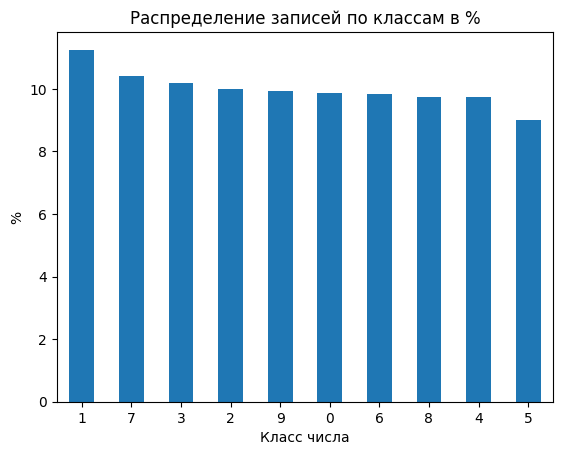

In [26]:
# Распределение классов
distrib_func(
    'digit', nums_data, 'Класс числа',
    'Распределение записей по классам в %'
)

In [27]:
print(
    f'Средняя интенсивность пикселей по датасету: {
        np.mean(nums_data.iloc[:, :-1].values): .3f
    }'
)

# Средняя интенсивность пикселей по каждому классу
intens_data = nums_data.copy()
intens_data['mean_intens'] = None
intens_data['mean_intens'] = intens_data.apply(
    lambda row: row.iloc[:-2].mean(),
    axis=1
)
result = intens_data.groupby('digit')['mean_intens'].apply(
    lambda x: round(x.mean(), 3)
)
print('Средняя интенсивность пикселей по каждому классу:')
display(result)


Средняя интенсивность пикселей по датасету:  33.386
Средняя интенсивность пикселей по каждому классу:


digit
0    44.177
1    19.407
2    38.034
3    36.154
4    30.996
5    32.950
6    35.235
7    29.218
8    38.398
9    31.359
Name: mean_intens, dtype: float64

Доля полностью черных или почти пустых изображений: 0.027 %


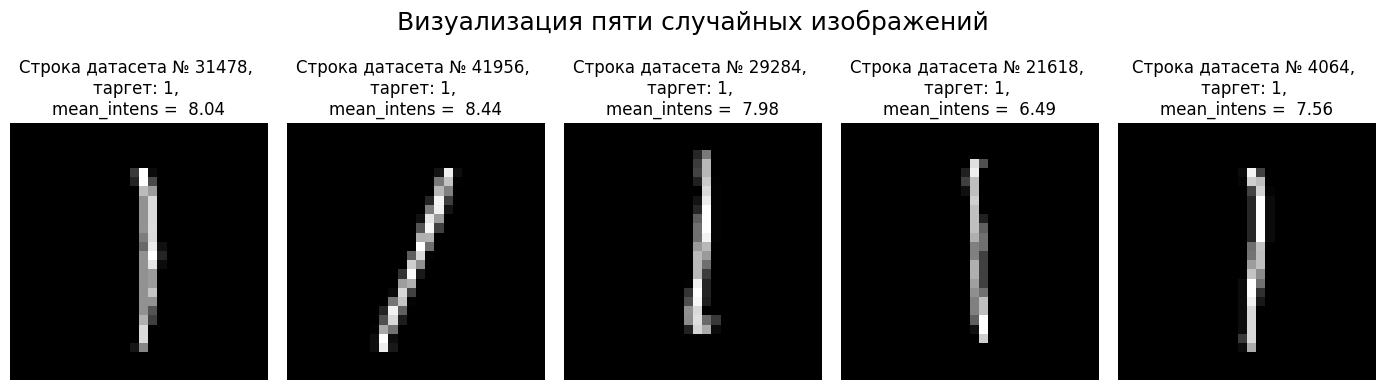

In [28]:
# Доля полностью черных или почти пустых изображений

def fully_black_check(row: pd.Series) -> int:
    """
    Выполняет проверку чрезмерной затемнённости изображения.
 
    Args:
        row (pd.Series): строка датафрейма.

    Returns:
        too_dark(int): метка затемнённости.
    """

    intens_np = np.array(row.iloc[:-2])
    intens_np = (intens_np > 38).astype(int).sum()

    # Изображение обозначается как too_dark,
    # если количество светлых пикселей меньше 39 (5 %)
    too_dark = 1 if intens_np < 39 else 0
    return too_dark

intens_data['fully_black'] = None
intens_data['fully_black'] = intens_data.apply(fully_black_check, axis=1)
fully_black_cnt = intens_data[intens_data['fully_black'] == 1].shape[0]

print(f'Доля полностью черных или почти пустых изображений: {
    round(fully_black_cnt * 100 / nums_data.shape[0], 3)
} %')

# Проверка результатов, относимых к затемнённым
black_rows = np.array(intens_data[intens_data['fully_black'] == 1].index)
black_rows = np.random.choice(black_rows, size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
for i, row_num in enumerate(black_rows):
    row_data = intens_data.iloc[row_num, :-3].values
    img = row_data.reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f"Строка датасета № {row_num}, \n" 
        f"таргет: {intens_data.iloc[row_num, 784]}, \n" 
        f"mean_intens = {intens_data.iloc[row_num, 785]: .2f}"
    )
    axes[i].axis('off')

plt.suptitle(
    "Визуализация пяти случайных изображений", 
    fontsize=18, 
    y=1.1
)
plt.tight_layout()
plt.show()

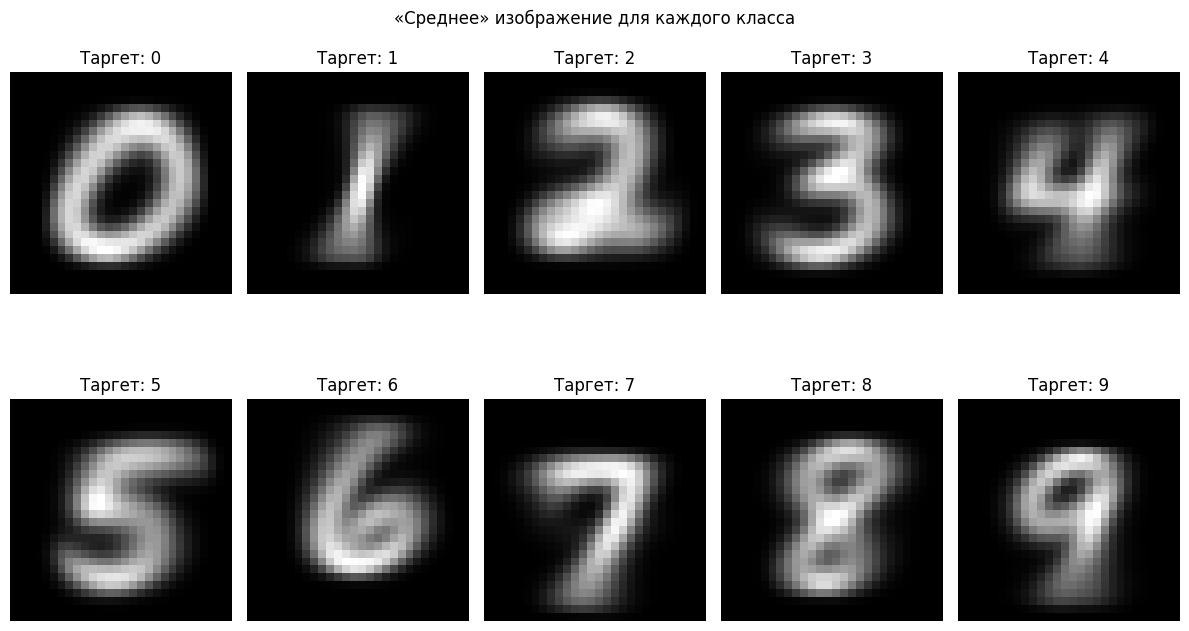

In [29]:
# «Среднее» изображение для каждого класса
mean_intens_dict = {}
for i in range(10):
    i_data_np = nums_data[nums_data['digit'] == i].iloc[:, :-1].values
    mean_intens_dict[i] = np.mean(i_data_np, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(12, 8))
k = 0
for i in range(2):
    for j in range(5):
        ax = axes[i, j]
        img = mean_intens_dict[k].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Таргет: {k}")
        ax.axis('off')
        k += 1
plt.suptitle("«Среднее» изображение для каждого класса", y=0.9)
plt.tight_layout()
plt.show()

**<Вывод>**  
1 Существенный дисбаланс классов в датасете отсутствует. Наиболее многочисленным является класс "1" (более 11 % изображений), наименее многочисленным - "5" (менее 10 % изображений).  
2 Классы различаются по средней интенсивности пикселей, т.к. количество ярких писелей, требуемое для отображения различных цифр неодинаково. Например, меньше всего ярких пикселей требуется для отображения единицы, поэтому средняя интенсивность пикселей этого класса (19,4) существенно меньше средней по датасету (33,4). С другой стороны, большое количество ярких пикселей требуется для отображения цифр 0 (средняя интенсивность 44,2), 2 (38,0), 8 (38,4). Средние интенсивности для них превышают среднее значение по датасету.  
3 Для выявления полностью черных / почти пустых изображений был принят порог интенсивности пиксей, равный 38. Изображение классифицировалось как затемнённое если данный порог не превышался для 5 % пикселей. Было выявлено, что во всех случаях к затемнённым относятся изображения единицы, что может быть связано и с наименьшим количеством ярких пикселей, требующихся для её отрисовки. На затемнённые изображения приходится около 0,03 % записей.    
4 "Средние" изображения для классов сохраняют визуальную различимость, благодаря размещению цифр близко к центру изображений, что упрощает задачу классификации.

## Задание 3. Финальная подготовка

В данном случае предобработка изображений упрощена, поскольку данные уже представлены в виде таблицы пикселей. Однако для повышения качества будущих моделей можно применить кое-какие преобразования:

1. Если ранее обнаружились проблемы с данными, устраните их подходящим методом.  
2. Разделите датасет на обучающую, валидационную и тестовую выборки в соотношении 70/15/15 с фиксированным `random_state=42`. Не забудьте учесть дисбаланс классов при необходимости.
3. Масштабируйте изображения подходящим способом (методы sklearn использовать необязательно, можно вручную).

Обоснуйте выбор методов и проделанные шаги в кратком выводе.

In [30]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Масштабирование изображений
X = nums_data.iloc[:, :-1].values / 255
y = nums_data['digit']

# train и test+val 
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    stratify=y, 
    test_size=0.3,
    random_state=42
)

# test и val 
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    stratify=y_temp, 
    test_size=0.5,  
    random_state=42
)

print('Размеры выборок')
print('Train:', X_train.shape)
print('Val:', X_val.shape)
print('Test:', X_test.shape, '\n')

print('Распределение таргета в выборках')
print(
    'Обучающая выборка:\n', y_train.value_counts(normalize=True), 
    '\n', sep=''
)
print(
    'Валидационная выборка:\n', y_val.value_counts(normalize=True), 
    '\n', sep=''
)
print(
    'Тестовая выборка:\n', 
    y_test.value_counts(normalize=True), 
    '\n', sep=''
)

Размеры выборок
Train: (49000, 784)
Val: (10500, 784)
Test: (10500, 784) 

Распределение таргета в выборках
Обучающая выборка:
digit
1    0.112531
7    0.104184
3    0.102020
2    0.099857
9    0.099408
0    0.098612
6    0.098224
8    0.097490
4    0.097490
5    0.090184
Name: proportion, dtype: float64

Валидационная выборка:
digit
1    0.112476
7    0.104190
3    0.102000
2    0.099905
9    0.099333
0    0.098571
6    0.098286
4    0.097524
8    0.097524
5    0.090190
Name: proportion, dtype: float64

Тестовая выборка:
digit
1    0.112571
7    0.104190
3    0.102000
2    0.099810
9    0.099429
0    0.098667
6    0.098190
8    0.097524
4    0.097429
5    0.090190
Name: proportion, dtype: float64



**<Вывод>**  
1 Выявленные затемнённые изображения принято не удалять из датасета, т.к. они сохраняют визуальную различимость и правильно классифицированы.  
2 В данном случае все параметры - интенсивности пикселей - уже находятся в одном масштабе. Масштабирование их в диапазон [0, 1] выполняется для обеспечения дополнительной численной стабильности применяемых далее алгоритмов (в первую очередь, линейных).

## Задание 4. Моделирование: baseline

В любых проектах сначала разрабатывают MVP (minimum viable product) — простейшее рабочее решение. В части ML-моделирования таковыми могут выступать baseline-алгоритмы — простейшие линейные модели. Поэтому с них и начнем:
1. Выберите наиболее подходящую метрику(метрики), на которую будете далее ориентироваться при сравнении моделей и для оценки качества в целом.
2. Попробуйте не менее двух линейных алгоритмов (гиперпараметры можно не подбирать).
3. Оцените качество по выбранной метрике и замерьте время обучения и инференса алгоритмов.
4. Являются ли данные линейно разделимыми? Наблюдается ли недообучение/переобучение (если есть переобучение, попробуйте его исправить методами регуляризации)? Что скажете про времязатратность процесса?

Обоснуйте все мысли в кратком выводе.

In [31]:
"""
ВАШЕ РЕШЕНИЕ
"""   

def poly_class_metrics(
    y_true: np.ndarray, 
    y_proba: np.ndarray, 
    y_pred: np.ndarray):

    """
    Функция расчитывает метрики F1_score и ROC_AUC_score.

    Args:
        y_true (np.ndarray): массив истинных значений целевой
        переменной.
        y_pred (np.ndarray): массив предсказанных значений целевой
        переменной.
    """

    print(f'F1-мера: {
    np.sqrt(metrics.f1_score(y_true, y_pred, average='weighted'))
    }')
    print(f'ROC_AUC_score: {
    metrics.roc_auc_score(
        y_true, 
        y_proba, 
        multi_class='ovr', 
        average='weighted')
    }')

In [32]:
# Логистическая регрессия
model_log = linear_model.LogisticRegression(
    max_iter=1000, solver='saga', C=np.inf, random_state=42
)

In [33]:
%%time
model_log.fit(X_train, y_train)
y_pred_test = model_log.predict(X_test)

CPU times: user 15min 43s, sys: 47.9 ms, total: 15min 43s
Wall time: 15min 43s


In [34]:
print('Результаты для логистической регрессии')
print('==================================================')
y_pred_train = model_log.predict(X_train)
y_proba_train = model_log.predict_proba(X_train)
y_proba_test = model_log.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для логистической регрессии
Результаты для обучающей выборки
F1-мера: 0.9725863009072556
ROC_AUC_score: 0.9967916088533393
Результаты для тестовой выборки
F1-мера: 0.9548955678053975
ROC_AUC_score: 0.991719142718763


In [35]:
# Логистическая регрессия с l1-регуляризацией
model_log = linear_model.LogisticRegression(
    max_iter=1000, solver='saga', l1_ratio=1, C=0.3, random_state=42
)

In [36]:
%%time
model_log.fit(X_train, y_train)
y_pred_test = model_log.predict(X_test)

CPU times: user 21min 57s, sys: 56.9 ms, total: 21min 57s
Wall time: 21min 57s


In [37]:
print('Результаты для логистической регрессии с l1-регуляризацией')
print('==================================================')
y_pred_train = model_log.predict(X_train)
y_proba_train = model_log.predict_proba(X_train)
y_proba_test = model_log.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для логистической регрессии с l1-регуляризацией
Результаты для обучающей выборки
F1-мера: 0.9665241423284523
ROC_AUC_score: 0.9951948792140085
Результаты для тестовой выборки
F1-мера: 0.9577347164058317
ROC_AUC_score: 0.992875904327443


In [15]:
# Метод опорных векторов с ядром linear
model_svm = svm.SVC(
    kernel='linear', class_weight='balanced', 
    probability=True, C=1e-6, random_state=42
)

In [16]:
%%time
model_svm.fit(X_train, y_train)
y_pred_test = model_svm.predict(X_test)

CPU times: user 2h 37min 1s, sys: 31.5 s, total: 2h 37min 33s
Wall time: 2h 37min 34s


In [17]:
print('Результаты для метода опорных векторов с ядром linear')
print('==================================================')
y_pred_train = model_svm.predict(X_train)
y_proba_train = model_svm.predict_proba(X_train)
y_proba_test = model_svm.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для метода опорных векторов с ядром linear
Результаты для обучающей выборки
F1-мера: 0.24600665975109243
ROC_AUC_score: 0.9507855167983317
Результаты для тестовой выборки
F1-мера: 0.2461223405162313
ROC_AUC_score: 0.9497686801860623


In [38]:
# Метод опорных векторов с ядром linear и l2-регуляризацией
model_svm = svm.SVC(
    kernel='linear', class_weight='balanced', 
    probability=True, C=0.3, random_state=42
)

In [39]:
%%time
model_svm.fit(X_train, y_train)
y_pred_test = model_svm.predict(X_test)

CPU times: user 7min 37s, sys: 83.1 ms, total: 7min 37s
Wall time: 7min 37s


In [40]:
print("""
    Результаты для метода опорных векторов с ядром linear
    и l2-регуляризацией
""")
print('==================================================')
y_pred_train = model_svm.predict(X_train)
y_proba_train = model_svm.predict_proba(X_train)
y_proba_test = model_svm.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)


    Результаты для метода опорных векторов с ядром linear
    и l2-регуляризацией

Результаты для обучающей выборки
F1-мера: 0.9833922048524566
ROC_AUC_score: 0.9985771119448632
Результаты для тестовой выборки
F1-мера: 0.968238951317945
ROC_AUC_score: 0.9963265397147167


**<Вывод>**  

1 Для оценки точности модели и сравнения моделей между собой были выбраны метрики F1-мера и ROC_AUC_score. Решение применять F1-меру, как гармоническое среднее между Precision и Recall было принято исходя из предположения, что модель может использоваться для решения бизнес-задач с равной важностью недопущения ошибок как первого, так и второго рода. Метрика ROC_AUC_score применяется, потому что она не зависит от порога вероятности и в целом указывает на степень способности модели различать классы, а данное задание в целом предполагает сравнение различных типов моделей.  
2 Для решения задачи были применены алгоритм логистической регрессии и метод опорных векторов с ядром linear. В целом оба алгоритма обеспечили высокую точность классификации, указывающую на линейную разделимость данных. На тестовой выборке метрики F1-мера и ROC_AUC_score для логистической регрессии составили 0,955 и 0,992; для метода опорных векторов - 0,246 и 0,950.  
3 Была зафиксирована высокая времязатратность работы алгоритмов, особенно метода опорных векторов с ядром linear и дефолтными гиперпараметрами (2 часа 37 минут). Также обнаружено низкое качество, обеспечиваемое методом опорных векторов по F1-мере.  
4 Обе линейные модели показывают высокие результаты по ROC_AUC_score, которые могут указывать на переобучение. Поэтому дальнейшее повышение точности моделей было обеспечено регуляризацией. Метрики F1-мера и ROC_AUC_score составили: для логистической регрессии 0,958 и 0,993; для метода опорных векторов - 0,968 и 0,996.  
5 Применение l1-регуляризации к логистической регрессии увечило время работы алгоритма с 943 до 1317 с, т.к. при этом функция потерь становится менее плавной и ухудшается сходимость алгоритма (скачкообразные изменения градиента при нулевых весах).  
6 С другой стороны, для метода опорных векторов регуляризация (l2) обеспечила сокращение времени работы алгоритма с 9454 до 457 с за счёт сокращения пространства поиска оптимального решения - у более "жёсткой" модели были упрощены условия сходимости (в первую очередь, отразилось на улучшении F1-меры).

## Задание 5. Моделирование: деревянные алгоритмы

Теперь попробуем нелинейные алгоритмы:
1. Возьмите два «деревянных» алгоритма из sklearn — дерево решений и какой-нибудь ансамбль на его основе. Обучите для начала на базовых гиперпараметрах, аналогично замерьте время работы.
2. Посмотрите на качество по выбранной метрике на train/test. Если заметили переобучение/недообучение, попробуйте вручную подкрутить подходящие гиперпараметры, чтобы хоть как-то это исправить, и снова оцените по метрикам. В выводе обоснуйте, почему сделали тот или иной выбор.
3. Стало ли лучше по сравнению с baseline? Что скажете про времязатратность процесса — оправданно ли использование более сложных алгоритмов?

Обоснуйте все мысли в кратком выводе.

In [42]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Дерево решений из sklearn
model_dtr = tree.DecisionTreeClassifier(
    random_state=42
)

In [43]:
%%time
model_dtr.fit(X_train, y_train)
y_pred_test = model_dtr.predict(X_test)

CPU times: user 10.8 s, sys: 57.1 ms, total: 10.9 s
Wall time: 10.6 s


In [44]:
print('Результаты для дерева решений')
print('==================================================')
y_pred_train = model_dtr.predict(X_train)
y_proba_train = model_dtr.predict_proba(X_train)
y_proba_test = model_dtr.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для дерева решений
Результаты для обучающей выборки
F1-мера: 1.0
ROC_AUC_score: 1.0
Результаты для тестовой выборки
F1-мера: 0.9312672139223105
ROC_AUC_score: 0.9264566292223544


In [199]:
# Дерево решений из sklearn с настройкой параметров
model_dtr = tree.DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    #min_samples_leaf=3,
    random_state=42
)

In [200]:
%%time
model_dtr.fit(X_train, y_train)
y_pred_test = model_dtr.predict(X_test)

CPU times: user 7.08 s, sys: 51.9 ms, total: 7.13 s
Wall time: 6.84 s


In [201]:
print("""
    Результаты для дерева решений
    с настройкой параметров
""")
print('==================================================')
y_pred_train = model_dtr.predict(X_train)
y_proba_train = model_dtr.predict_proba(X_train)
y_proba_test = model_dtr.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)


    Результаты для дерева решений
    с настройкой параметров

Результаты для обучающей выборки
F1-мера: 0.9780320648086754
ROC_AUC_score: 0.997987646956067
Результаты для тестовой выборки
F1-мера: 0.9320987542939972
ROC_AUC_score: 0.9301504725006741


In [45]:
# Случайный лес из sklearn
model_rf = ensemble.RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

In [46]:
%%time
model_rf.fit(X_train, y_train)
y_pred_test = model_rf.predict(X_test)

CPU times: user 50.7 s, sys: 470 ms, total: 51.1 s
Wall time: 4.33 s


In [47]:
print('Результаты для случайного леса')
print('==================================================')
y_pred_train = model_rf.predict(X_train)
y_proba_train = model_rf.predict_proba(X_train)
y_proba_test = model_rf.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для случайного леса
Результаты для обучающей выборки
F1-мера: 1.0
ROC_AUC_score: 1.0
Результаты для тестовой выборки
F1-мера: 0.9818212527204433
ROC_AUC_score: 0.9988852898125337


In [48]:
# Случайный лес из sklearn с настройкой параметров
model_rf = ensemble.RandomForestClassifier(
    n_jobs=-1,
    n_estimators=500,
    max_features = 200,
    random_state=42
)

In [49]:
%%time
model_rf.fit(X_train, y_train)
y_pred_test = model_rf.predict(X_test)

CPU times: user 30min 49s, sys: 3.09 s, total: 30min 52s
Wall time: 1min 58s


In [50]:
print("""
    Результаты для случайного леса
    с настройкой параметров
""")
print('==================================================')
y_pred_train = model_rf.predict(X_train)
y_proba_train = model_rf.predict_proba(X_train)
y_proba_test = model_rf.predict_proba(X_test)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)


    Результаты для случайного леса
    с настройкой параметров

Результаты для обучающей выборки
F1-мера: 1.0
ROC_AUC_score: 1.0
Результаты для тестовой выборки
F1-мера: 0.9824075136524966
ROC_AUC_score: 0.9989393619459387


**<Вывод>**  
1 Применение «деревянных» алгоритмов позволило существенно сократить время обучения - не превышает двух минут.  
2 При дефолтных гиперпараметрах на тестовой выборке метрики F1-мера и ROC_AUC_score составили: для дерева решений 0,9313 и 0,9265; для случайного леса 0,9818 и 0,9989.  
3 Для дерева решений метрики на тесте получились существенно хуже, чем при обучении, поэтому, чтобы снизить переобучения было установлено ограничение для максимальной глубины (max_depth=15) и увеличено минимальное число образцов для разбиения (min_samples_split=10). Выполненные настройки обеспечили на тесте улучшение метрк F1-мера и ROC_AUC_score: 0,9321 и 0,9302.  
4 Для случайного леса дефолтные настройки обеспечили результат, практически нетребующий улучшения. Для улучшения стабильности и обобщающей способности модели число деревьев было увеличено до 500. Также, как поправка на большое количество параметров, увеличено количество признаков, которые модель выбирает случайным образом при разбиениях на узлах деревьев (max_features = 200). Выполненные настройки обеспечили повышение F1-меры на тесте до 0,9824 при дальнейшем несущественном повышении ROC_AUC_score.

## Задание 6. Моделирование: тяжелая артиллерия

Давайте обратимся к традиционно самым эффективным реализациям алгоритмов для табличных данных — продвинутым библиотекам CatBoost, XGBoost, LightGBM:

1. Выберите наиболее подходящий алгоритм и теоретически обоснуйте свой выбор /отличия от других невыбранных бустингов.
2. Обучите этот алгоритм, используя встроенные в библиотеку классы для датасетов (не возбраняется, если попробуете несколько алгоритмов, но достаточно будет и одного).
3. Подберите к нему гиперпараметры (не менее 5 шт.), используя специальные инструменты (не в цикле). Удалось ли улучшить качество? И что насчет временных затрат?

Обоснуйте все мысли в кратком выводе.

In [72]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Пулы для CatBoostClassifier
train_pool = cb.Pool(
    X_train,
    label=y_train
)
valid_pool = cb.Pool(
    X_val,
    label=y_val
)
test_pool = cb.Pool(
    X_test,
    label=y_test
)

# Модель CatBoost с дефолтными параметрами
model_CBC = cb.CatBoostClassifier(
    verbose=0, random_seed=42
)

In [73]:
%%time
model_CBC.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)
y_pred_test = model_CBC.predict(test_pool)

CPU times: user 1h 50min 15s, sys: 2min 39s, total: 1h 52min 54s
Wall time: 7min 13s


In [74]:
print('Результаты для CatBoost с дефолтными параметрами')
print('==================================================')
y_pred_train = model_CBC.predict(train_pool)
y_proba_train = model_CBC.predict_proba(train_pool)
y_proba_test = model_CBC.predict_proba(test_pool)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для CatBoost с дефолтными параметрами
Результаты для обучающей выборки
F1-мера: 0.9939800076137029
ROC_AUC_score: 0.9998779004910897
Результаты для тестовой выборки
F1-мера: 0.984534908168123
ROC_AUC_score: 0.9991934852383896


In [58]:
def objective(trial) -> float:
    """
    Функция для оптимизации CatBoostClassifier по 
    метрике roc_auc_score.
    """
    # Оптимизируемые гиперпараметры
    params = {
        'depth': trial.suggest_int('depth', 1, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.5),
        'iterations': 1000,
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.5, 10),
        'random_seed': 42,
        'eval_metric': 'AUC',
        'use_best_model': True,
        'verbose': 0, 
        'border_count': trial.suggest_int('border_count', 32, 255),   # для числовых фич
        'bagging_temperature': trial.suggest_uniform('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_uniform('random_strength', 0, 10)
    }

    model = cb.CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool)

    y_proba_val = model.predict_proba(valid_pool)
    auc = metrics.roc_auc_score(
        y_val, 
        y_proba_val,
        multi_class='ovr', 
        average='weighted'
    )

    return auc

In [60]:
# Поиск лучших параметров
sampler = TPESampler(seed=42) 
study = optuna.create_study(sampler=sampler, direction='maximize')
study.optimize(objective, n_trials=50, timeout=5400) 

# Лучшие параметры
print("Лучший ROC_AUC_score на валидационной выборке:", end=' ')
print(study.best_value)
print("Лучшие гиперпараметры:")
print(
    *(f'{key} = {value}' for key, value in study.best_params.items()), 
    sep='\n'
)

[I 2026-04-03 06:29:10,669] A new study created in memory with name: no-name-cac45e65-98c6-41d4-96dc-0cedacd59fd7
[I 2026-04-03 06:30:44,907] Trial 0 finished with value: 0.999099258036498 and parameters: {'depth': 4, 'learning_rate': 0.36808608148776095, 'l2_leaf_reg': 4.480392682684062, 'border_count': 166, 'bagging_temperature': 0.15601864044243652, 'random_strength': 1.5599452033620265}. Best is trial 0 with value: 0.999099258036498.
[I 2026-04-03 06:31:38,542] Trial 1 finished with value: 0.9937828840775327 and parameters: {'depth': 1, 'learning_rate': 0.21766241123453672, 'l2_leaf_reg': 3.027182927734624, 'border_count': 190, 'bagging_temperature': 0.020584494295802447, 'random_strength': 9.699098521619943}. Best is trial 0 with value: 0.999099258036498.
[I 2026-04-03 06:48:36,144] Trial 2 finished with value: 0.9976948038615007 and parameters: {'depth': 9, 'learning_rate': 0.003741940611118496, 'l2_leaf_reg': 0.8620446097910766, 'border_count': 73, 'bagging_temperature': 0.30424

Лучший ROC_AUC_score на валидационной выборке: 0.9995816199516906
Лучшие гиперпараметры:
depth = 6
learning_rate = 0.30768824743015377
l2_leaf_reg = 0.6517805612564437
border_count = 75
bagging_temperature = 0.045227288910538066
random_strength = 3.2533033076326436


In [75]:
# Обучение модели на лучших гиперпараметрах

# Оптиммальный набор параметров
params = {
    'depth': 6,
    'learning_rate': 0.30768824743015377,
    'iterations': 1000,
    'l2_leaf_reg': 0.6517805612564437,
    'random_seed': 42,
    'eval_metric': 'AUC',
    'use_best_model': True,
    'verbose': 0, 
    'border_count': 75,   # для числовых фич
    'bagging_temperature': 0.045227288910538066,
    'random_strength': 3.2533033076326436
}

model_CBC = cb.CatBoostClassifier(**params)

In [76]:
%%time
model_CBC.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)
y_pred_test = model_CBC.predict(test_pool)

CPU times: user 1h 16min 27s, sys: 2min 48s, total: 1h 19min 16s
Wall time: 5min 3s


In [77]:
print('Результаты для CatBoost с оптимальными параметрами')
print('==================================================')
y_pred_train = model_CBC.predict(train_pool)
y_proba_train = model_CBC.predict_proba(train_pool)
y_proba_test = model_CBC.predict_proba(test_pool)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для CatBoost с оптимальными параметрами
Результаты для обучающей выборки
F1-мера: 1.0
ROC_AUC_score: 1.0
Результаты для тестовой выборки
F1-мера: 0.9885931648279156
ROC_AUC_score: 0.9995065879127912


**<Вывод>**  
1 Для решения поставленной задачи был выбран алгоритм CatBoostClassifier по следующим причинам:  
* среди перечисленных моделей CatBoost обладает наибольшей точностью. Высокая точность модели связана с применением стратегии обучения по слоям;  
* стратегия обучения по слоям обуславливает повышенную ресурсоёмкость модели. Однако, в данном случае размер датасета сравнительно небольшой и снижание скорости расчёта в пользу повышения его точности принимается допустимым;  
* используемые в задаче данные для обучения являются "шумными", т.к. одни и те же результаты могут соответствовать интенсивностям пикселей с некоторыми флуктуациями. Благодаря тому, что CatBoost имеет встроенные методы регуляризации, его результаты более устойчивы к шуму;
* он беспечивает высокую точность по дефолтным гиперпараметрам, ввод которых у этой модели не является обязательным.

2 При расчёте по дефолтным гиперпараметрам на тесте метрики F1-мера и ROC_AUC_score составили 0,9845 и 0,9992. Расчёт занял 433 с.  
3 Модель оптимизировалась по гиперпараметрам: depth, learning_rate, l2_leaf_reg, border_count, bagging_temperature, random_strength.  
4 При расчёте по оптимизированным гиперпараметрам на тесте метрики F1-мера и ROC_AUC_score составили 0,9886 и 0,9995. Расчёт занял 303 с.   
5 Таким образом, по сравнению со случайным лесом, модель CatBoost медленнее более чем в два раза, а разница в точности двух моделей незначительна.

## Задание 7. Оптимизация датасета

Помимо качества модели весьма важным критерием при выборе итогового решения является также ресурсоемкость и временные затраты — особенно для онлайн-решений, при больших датасетах или если нужно часто переобучать модель.

Как оптимизировать процесс? Когда терять качество модели не хочется, можно избавиться от лишних признаков. Особенно если их много, скорее всего, большая часть из них будет не слишком полезна.

В рамках этого задания попробуйте:
1. Применить PCA для понижения размерности, итоговое количество признаков подберите самостоятельно, опираясь на численные показатели (какие — обоснуйте в выводе).
2. Обучите на модифицированных данных наилучшую модель из предыдущих заданий (если ранее подбирали гиперпараметры, то можно повторно не делать).
3. Комплексно оцените качество и скорость работы модели. Насколько удалось ускорить решение и какой ценой? Какой вариант рекомендовали бы для финального production-решения?

Обоснуйте все мысли в кратком выводе.

In [192]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Подбор количества признаков
n_params = 784
min_n_params = 784
result_sum_var = 0
patience = 200
no_improve_cnt = 0
var_tol = 0.95
best_model_pca = None

while n_params > 0:
    pca = PCA(n_components=n_params)
    pca.fit(X_train)
    cur_sum_var = pca.explained_variance_ratio_.sum()

    # проверка на раннюю остановку
    if cur_sum_var >= var_tol:
        min_n_params = n_params
        result_sum_var = cur_sum_var
        best_model_pca = pca
    else:
        no_improve_cnt += 1
    if no_improve_cnt >= patience:
        break

    n_params -= 1

print(f'Итоговое количество признаков: {min_n_params}')
print(
    'Обеспечиваемая суммарная доля объясненной дисперсии:',
    round(result_sum_var, 4)
)

Итоговое количество признаков: 154
Обеспечиваемая суммарная доля объясненной дисперсии: 0.9504


In [193]:
# Трансформация выборок
X_train_pca = best_model_pca.transform(X_train)
X_val_pca = best_model_pca.transform(X_val)
X_test_pca = best_model_pca.transform(X_test)

# Пулы для CatBoostClassifier
train_pool_pca = cb.Pool(
    X_train_pca,
    label=y_train
)
valid_pool_pca = cb.Pool(
    X_val_pca,
    label=y_val
)
test_pool_pca = cb.Pool(
    X_test_pca,
    label=y_test
)

In [194]:
%%time
model_CBC.fit(
    train_pool_pca,
    eval_set=valid_pool_pca,
    use_best_model=True
)
y_pred_test = model_CBC.predict(test_pool_pca)

CPU times: user 26min 29s, sys: 1min 59s, total: 28min 29s
Wall time: 1min 51s


In [195]:
print('Результаты для CatBoost по главным компонентам')
print('==================================================')
y_pred_train = model_CBC.predict(train_pool_pca)
y_proba_train = model_CBC.predict_proba(train_pool_pca)
y_proba_test = model_CBC.predict_proba(test_pool_pca)

print('Результаты для обучающей выборки')
poly_class_metrics(y_train, y_proba_train, y_pred_train)

print('Результаты для тестовой выборки')
poly_class_metrics(y_test, y_proba_test, y_pred_test)

Результаты для CatBoost по главным компонентам
Результаты для обучающей выборки
F1-мера: 1.0
ROC_AUC_score: 1.0
Результаты для тестовой выборки
F1-мера: 0.9840442855524982
ROC_AUC_score: 0.9991420798957856


**<Вывод>**  
1 Подбор количества признаков (главных компонент), обеспечиваемых алгоритмом PCA выполнялся исходя из суммарной доли дисперсии, объясняемой этими компонентами. В качестве порогового значения доли для модели, предназначенной для коммерческого использования, было принято 0,95. Было выявлено, что для обеспечения этой доли достаточно 154 главных компонент.  
2 Метрики F1-мера и ROC_AUC_score для модели CatBoostClassifier, обученной по главным компонентам, на тесте составили: 0,9840 и 0,9991. Время расчётов при этом сократилось менее чем до 2 минут.    
3 Таким образом, после обучения по главным компонентам, метрики модели CatBoost несколько снизились, однако, она всё-равно осталась самой точной из рассмотренных. При этом по быстродействию модель сравнялась с RandomForestClassifier.  
4 Вариант для финального production-решения следует рекомендовать исходя из его назначения. Если будут требоваться частые повторные обучения модели, то необходимо выяснить является ли время ожидания в 2 минуты допустим для заказчика. Если время ожидания в 2 минуты является приемлемым, то следует рекомендовать модель CatBoost, которая будет обучаться по главным компонентам. Иначе может быть предложена простая модель DecisionTreeClassifier, которая решает задачу за несколько секунд, не требует выделения главных компонент и показывает приемлемую точность по метрикам F1-мера и ROC_AUC_score на тесте (примерно по 0,93 каждая). 

## Задание 8. Интерпретация результатов

Напоследок давайте сделаем еще несколько полезных визуализаций, которые будут интересны и нам для понимания данных и модели, и для презентаций заказчику:

1. Для финального выбранного решения постройте и визуализируйте матрицу ошибок на тестовом сете, чтобы наглядно проанализировать, какие классы путает модель. Зафиксируйте наблюдения в выводе.
2. Сделайте понижение размерности в 2D-пространство при помощи TSNE (гиперпараметры можете подобрать экспериментально) и визуализируйте полученную картину на scatterplot с раскраской по классам (таргетам). Хорошо ли данные разделяются в пространстве?

Не забудьте зафиксировать все наблюдения в выводе.

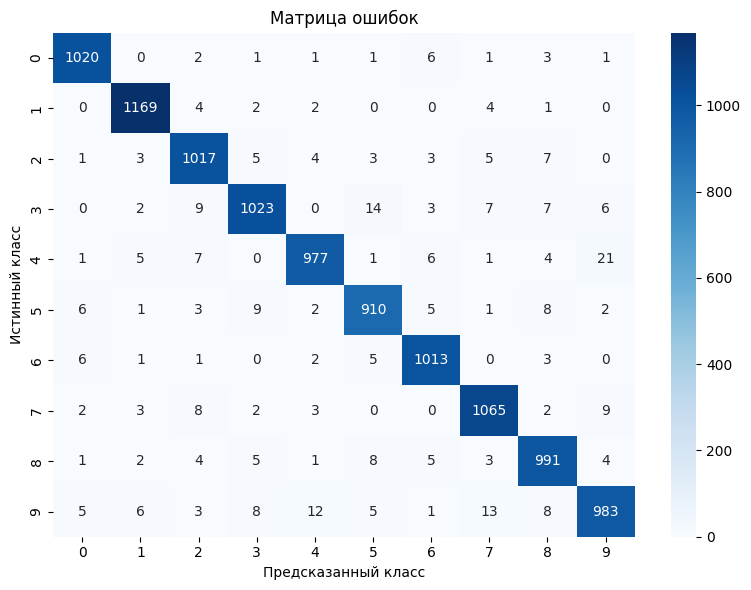

In [196]:
"""
ВАШЕ РЕШЕНИЕ
"""

# Confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.show()

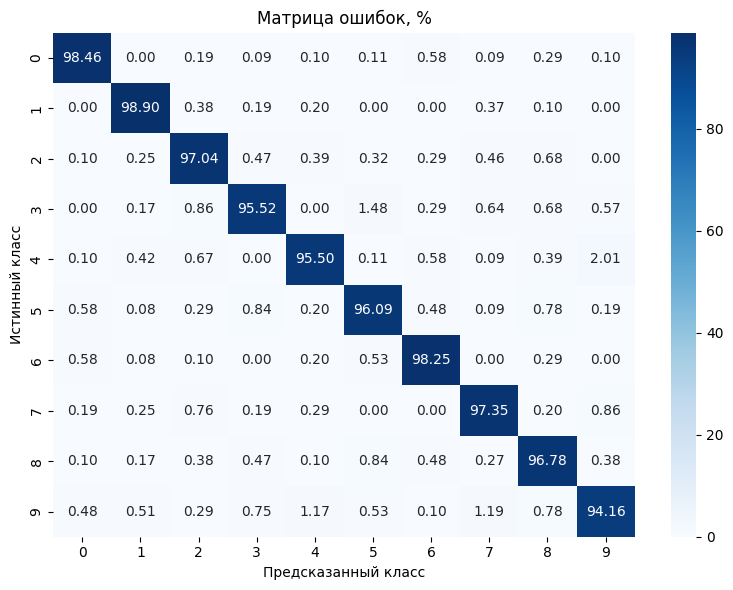

In [197]:
# в процентах
cm_percent = cm*100 / cm.sum(axis=1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок, %')
plt.tight_layout()
plt.show()

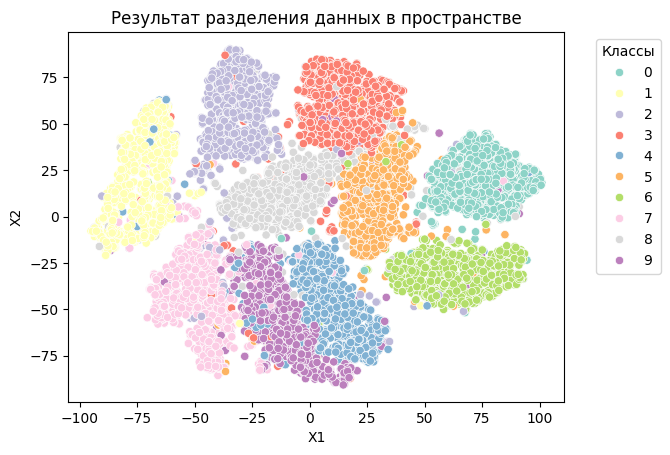

In [198]:
data_tsne = TSNE(
    n_components=2, perplexity=17,
    n_jobs=8, max_iter=1000, random_state=42
).fit_transform(X_test_pca)

# Визуализия на scatterplot
scatter = sns.scatterplot(
    x=data_tsne[:, 0], y=data_tsne[:, 1], hue=y_test, palette="Set3"
)
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(title='Классы', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Результат разделения данных в пространстве')
plt.show()

**<Вывод>**    
1 Матрица ошибок показывает, что наиболее точно модель обучена определять класс "1" - соответствующая цифра классифицируется верно в примерно 99 % случаев. Также моделью очень хорошо определяются классы "0" и "6" - соответствующая цифра классифицируется верно в примерно 98 % случаев.   
2 С другой стороны, наименее точно модель предсказывает класс "9" - соответствующая цифра классифицируется верно в 94 % случаев. Также сравнительно низкое качество классификации наблюдается дла классов "3" и "4" - для обоих около 95 % случаев.   
3 Алгоритм TSNE с подобранными гиперпараметрами обеспечил хорошее разделение данных в пространстве. Полученное разделение подтверждает выводы, сделанные по матрице ошибок: классы "0", "1", "6" очень выразительно выделяются из остальных, в то время как классы "4" и "9" смешиваются друг с другом, а отдельные экземпляры класса "3" сильно рассеяны по диаграмме.